In [23]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, TextVectorization, Flatten, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.regularizers import l1,l2
from tensorflow.keras.preprocessing.text import Tokenizer
from keras import optimizers, regularizers, initializers
import pandas as pd
from sklearn.model_selection import train_test_split
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
import re
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

In [24]:
tf.keras.utils.set_random_seed(0)
np.random.seed(0)

## Importing the dataset

The notebook assumes the two TREC files are available in the same working directory because the import for nltk does not work for me
- `train_5500.label`
- `TREC_10.label`

In [25]:
TRAIN_FILE = 'train_5500.label'
TEST_FILE = 'TREC_10.label'

def read_trec_file(filepath):
    texts = []
    labels = []

    with open(filepath, 'r', encoding='latin-1') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            first_space = line.find(' ')
            label_token = line[:first_space]
            question_text = line[first_space + 1:]

            coarse_label = label_token.split(':')[0]
            texts.append(question_text)
            labels.append(coarse_label)

    return pd.DataFrame({'text': texts, 'label': labels})

dataset_train = read_trec_file(TRAIN_FILE)  
dataset_test = read_trec_file(TEST_FILE)

dataset_train = shuffle(dataset_train, random_state=42).reset_index(drop=True)   
dataset_test = shuffle(dataset_test, random_state=42).reset_index(drop=True)

dataset_train.head()


,text,label
0,What city is served by Tempelhol Airport ?,LOC
1,What is Dudley Do-Right 's horse 's name ?,ENTY
2,What 's nature 's purpose for tornadoes ?,DESC
3,What is the history of Valentine 's Day cards ?,DESC
4,What President became Chief Justice after his ...,HUM


In [26]:
label_names = sorted(dataset_train['label'].unique())
label_to_index = {label: idx for idx, label in enumerate(label_names)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

x_full_train = dataset_train['text'].astype(str)
y_full_train = dataset_train['label'].map(label_to_index).to_numpy()

x_test = dataset_test['text'].astype(str)
y_test = dataset_test['label'].map(label_to_index).to_numpy() 

x_train, x_val, y_train, y_val = train_test_split(x_full_train,  y_full_train, test_size=0.15, random_state=42, stratify=y_full_train)

## TF-IDF representation
Each question is converted into one fixed-size vector using TF-IDF features for Approach A


In [27]:
tfidf_vectorizer = TfidfVectorizer(lowercase=True, stop_words=None, max_features=1000, ngram_range=(1, 1))

X_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
X_val_tfidf = tfidf_vectorizer.transform(x_val)
X_test_tfidf = tfidf_vectorizer.transform(x_test)

In [28]:
X_train_dense = X_train_tfidf.astype(np.float32).toarray()
X_val_dense = X_val_tfidf.astype(np.float32).toarray()
X_test_dense = X_test_tfidf.astype(np.float32).toarray()

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=len(label_names))
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=len(label_names))
y_test_cat = tf.keras.utils.to_categorical(y_test,num_classes=len(label_names))

## Helper functions

Reusable functions used by 2 or more of the models

In [29]:
def build_mlp_model(input_dim, hidden_units, dropout_rate=0.0, learning_rate=0.001, l2_value=0.0):
    model = Sequential()

    model.add(Dense(hidden_units[0], input_dim=input_dim, activation='relu', kernel_initializer='he_uniform', bias_initializer='zeros',
            kernel_regularizer=regularizers.l2(l2_value)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for units in hidden_units[1:]:
        model.add(Dense(units, activation='relu', kernel_initializer='he_uniform', bias_initializer='zeros', kernel_regularizer=regularizers.l2(l2_value)))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(len(label_names), activation='softmax'))

    opt = optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model


def plot_history(history, title_prefix):
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(history.history['accuracy'])
    axes[0].plot(history.history['val_accuracy'])
    axes[0].set_title(title_prefix + ' | Model Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(['Train', 'Validation'], loc='upper left')

    axes[1].plot(history.history['loss'])
    axes[1].plot(history.history['val_loss'])
    axes[1].set_title(title_prefix + ' | Model Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(['Train', 'Validation'], loc='upper left')

    plt.subplots_adjust(hspace=0.35)
    plt.show()


def predict_classes(model, X_dense):
    probs = model.predict(X_dense)
    return np.argmax(probs, axis=1)


def display_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)  
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.show()

## MLP 1

The first model is a simple MLP using TF-IDF question vectors as input

In [30]:
tf.keras.utils.set_random_seed(0)
mlp_1 = build_mlp_model(
    input_dim=X_train_dense.shape[1],
    hidden_units=[128],
    dropout_rate=0.20,
    learning_rate=0.001,
    l2_value=0.001 
)

c:\Users\mw710\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
history_mlp_1 = mlp_1.fit(
    X_train_dense,
    y_train_cat,
    validation_data=(X_val_dense, y_val_cat),
    epochs= 30,
    batch_size=32,
    verbose=2
)

Epoch 1/30
145/145 - 3s - 18ms/step - accuracy: 0.5045 - loss: 1.6093 - val_accuracy: 0.7225 - val_loss: 1.2435
Epoch 2/30
145/145 - 1s - 5ms/step - accuracy: 0.7594 - loss: 1.0185 - val_accuracy: 0.8007 - val_loss: 0.8804
Epoch 3/30
145/145 - 1s - 5ms/step - accuracy: 0.8267 - loss: 0.7799 - val_accuracy: 0.8044 - val_loss: 0.7859
Epoch 4/30
145/145 - 1s - 5ms/step - accuracy: 0.8552 - loss: 0.6925 - val_accuracy: 0.8032 - val_loss: 0.7521
Epoch 5/30
145/145 - 1s - 5ms/step - accuracy: 0.8632 - loss: 0.6460 - val_accuracy: 0.8007 - val_loss: 0.7333
Epoch 6/30
145/145 - 1s - 5ms/step - accuracy: 0.8809 - loss: 0.6056 - val_accuracy: 0.8056 - val_loss: 0.7218
Epoch 7/30
145/145 - 1s - 5ms/step - accuracy: 0.8824 - loss: 0.5872 - val_accuracy: 0.8105 - val_loss: 0.7130
Epoch 8/30
145/145 - 1s - 5ms/step - accuracy: 0.8899 - loss: 0.5653 - val_accuracy: 0.8130 - val_loss: 0.7033
Epoch 9/30
145/145 - 1s - 5ms/step - accuracy: 0.8938 - loss: 0.5453 - val_accuracy: 0.8154 - val_loss: 0.6989


In [32]:
loss_mlp_1, acc_mlp_1 = mlp_1.evaluate(X_test_dense, y_test_cat, verbose=0)
print('MLP 1 Test Accuracy: %.4f' % acc_mlp_1)
print('MLP 1 Test Loss:', loss_mlp_1)

MLP 1 Test Accuracy: 0.8380
MLP 1 Test Loss: 0.6391357779502869


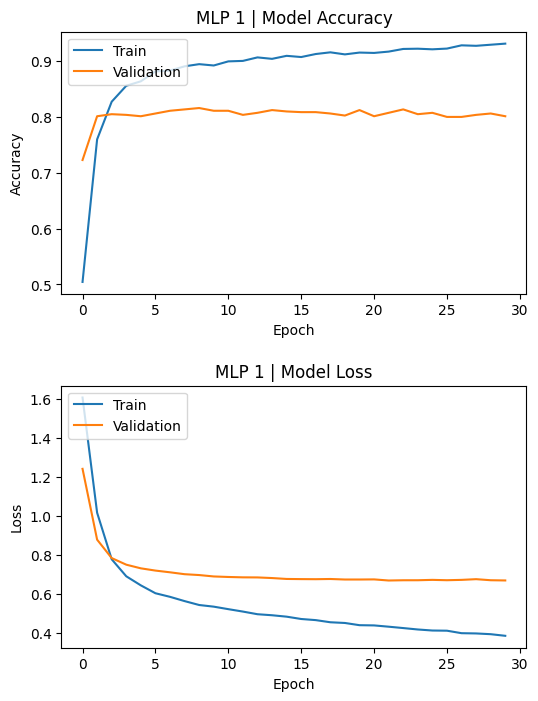

In [33]:
plot_history(history_mlp_1, 'MLP 1')

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


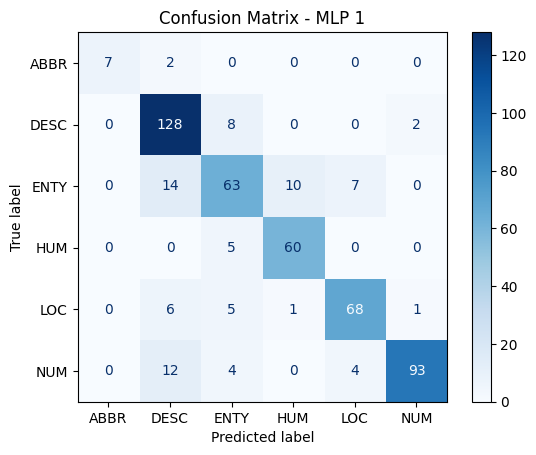

In [34]:
y_pred_mlp_1 = predict_classes(mlp_1, X_test_dense)
display_confusion_matrix(y_test, y_pred_mlp_1, 'Confusion Matrix - MLP 1')

## MLP 2

Represent each question as a sequence of pre-trained word embeddings

In [35]:
tf.keras.utils.set_random_seed(0)

num_words = 5000
tokenizer = Tokenizer(num_words=num_words, lower=True, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_val_seq = tokenizer.texts_to_sequences(x_val)
x_test_seq = tokenizer.texts_to_sequences(x_test)

max_length = 20

X_train_seq = tf.keras.preprocessing.sequence.pad_sequences(
    x_train_seq, maxlen=max_length, padding='post', truncating='post'
)
X_val_seq = tf.keras.preprocessing.sequence.pad_sequences(
    x_val_seq, maxlen=max_length, padding='post', truncating='post'
)
X_test_seq = tf.keras.preprocessing.sequence.pad_sequences(
    x_test_seq, maxlen=max_length, padding='post', truncating='post'
)

In [36]:
from gensim.scripts.glove2word2vec import glove2word2vec

# Define files
glove_input_file = 'glove.6B.300d.txt'
word2vec_output_file = 'glove.6B.300d.txt.word2vec'

# Convert GloVe to Word2Vec forma
# Only convert once to speed things up
import os
if not os.path.exists(word2vec_output_file):
    print("Converting GloVe to Word2Vec format")
    glove2word2vec(glove_input_file, word2vec_output_file)
else:
    print("Converted file already exists. Skipping conversion.")

# Load embeddings
embedding_model = KeyedVectors.load_word2vec_format(word2vec_output_file, binary=False, limit=5000) #change from 10000
embedding_dim = embedding_model.vector_size

# Build embedding matrix
vocab_size = min(num_words, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size, embedding_model.vector_size), dtype=np.float32)

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue

    vector = None

    # Direct match
    if word in embedding_model:
        vector = embedding_model[word]
    else:
        # Lowercase fallback
        lower_word = word.lower()
        if lower_word in embedding_model:
            vector = embedding_model[lower_word]
        else:
            # Cleaned falback
            cleaned_word = re.sub(r'[^a-z0-9]', '', lower_word)
            if cleaned_word and cleaned_word in embedding_model:
                vector = embedding_model[cleaned_word]

    if vector is not None:
        embedding_matrix[idx] = vector

Converted file already exists. Skipping conversion.


In [37]:
def build_embedding_mlp(vocab_size, embedding_dim, max_length, embedding_matrix,
                        dense_units, dropout_rate=0.0, learning_rate=0.001, l2_value=0.0,
                        trainable=False):
    model = Sequential()
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_length,
            trainable=trainable
        )
    )
    model.add(Flatten())

    for units in dense_units:
        model.add(Dense(units, activation='relu', kernel_initializer='he_uniform', bias_initializer='zeros', kernel_regularizer=regularizers.l2(l2_value)))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(len(label_names), activation='softmax'))

    opt = optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

mlp_2 = build_embedding_mlp(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    max_length=max_length,
    embedding_matrix=embedding_matrix,
    dense_units=[32],
    dropout_rate=0.50,
    learning_rate=0.001,
    l2_value=0.0005,
    trainable=False
)

c:\Users\mw710\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [38]:
history_mlp_2 = mlp_2.fit(
    X_train_seq,
    y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=30,
    batch_size=32,
    verbose=2
)

Epoch 1/30
145/145 - 2s - 15ms/step - accuracy: 0.5587 - loss: 1.2071 - val_accuracy: 0.7421 - val_loss: 0.8054
Epoch 2/30
145/145 - 1s - 5ms/step - accuracy: 0.7298 - loss: 0.8054 - val_accuracy: 0.7726 - val_loss: 0.6886
Epoch 3/30
145/145 - 1s - 5ms/step - accuracy: 0.7915 - loss: 0.6462 - val_accuracy: 0.7958 - val_loss: 0.6376
Epoch 4/30
145/145 - 1s - 5ms/step - accuracy: 0.8185 - loss: 0.5604 - val_accuracy: 0.7958 - val_loss: 0.6209
Epoch 5/30
145/145 - 1s - 5ms/step - accuracy: 0.8485 - loss: 0.5074 - val_accuracy: 0.7934 - val_loss: 0.6191
Epoch 6/30
145/145 - 1s - 5ms/step - accuracy: 0.8574 - loss: 0.4754 - val_accuracy: 0.8020 - val_loss: 0.6366
Epoch 7/30
145/145 - 1s - 5ms/step - accuracy: 0.8809 - loss: 0.4358 - val_accuracy: 0.7971 - val_loss: 0.6317
Epoch 8/30
145/145 - 1s - 5ms/step - accuracy: 0.8867 - loss: 0.4118 - val_accuracy: 0.8032 - val_loss: 0.6237
Epoch 9/30
145/145 - 1s - 6ms/step - accuracy: 0.8886 - loss: 0.4106 - val_accuracy: 0.8056 - val_loss: 0.6421


In [39]:
loss_mlp_2, acc_mlp_2 = mlp_2.evaluate(X_test_seq, y_test_cat, verbose=0)
print('MLP 2 Test Accuracy: %.4f' % acc_mlp_2)
print('MLP 2 Test Loss:', loss_mlp_2)

MLP 2 Test Accuracy: 0.8760
MLP 2 Test Loss: 0.5516430735588074


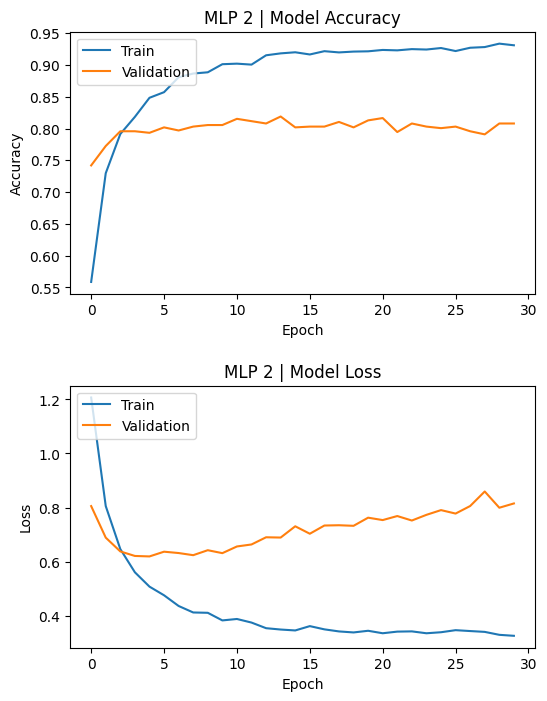

In [40]:
plot_history(history_mlp_2, 'MLP 2')

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


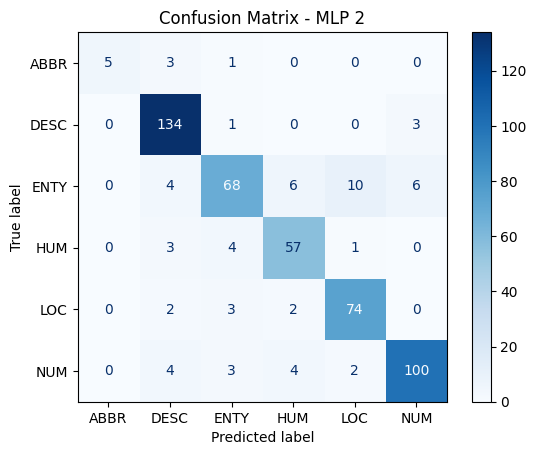

In [41]:
y_pred_mlp_2 = predict_classes(mlp_2, X_test_seq)
display_confusion_matrix(y_test, y_pred_mlp_2, 'Confusion Matrix - MLP 2')

## CNN

Epoch 1/10


c:\Users\mw710\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4199 - loss: 1.4310 - val_accuracy: 0.7335 - val_loss: 0.8613
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6795 - loss: 0.8631 - val_accuracy: 0.8093 - val_loss: 0.5834
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7728 - loss: 0.6490 - val_accuracy: 0.8203 - val_loss: 0.5070
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8168 - loss: 0.5002 - val_accuracy: 0.8130 - val_loss: 0.5239
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8507 - loss: 0.4244 - val_accuracy: 0.8325 - val_loss: 0.4827
Epoch 6/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8800 - loss: 0.3470 - val_accuracy: 0.8313 - val_loss: 0.4747
Epoch 7/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9027 - loss: 0.2841 - val_accuracy: 0.8423 - val_loss: 0.5170
Epoch 8/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9169 - loss: 0.2342 - val_accuracy: 0.842

<Figure size 600x500 with 0 Axes>

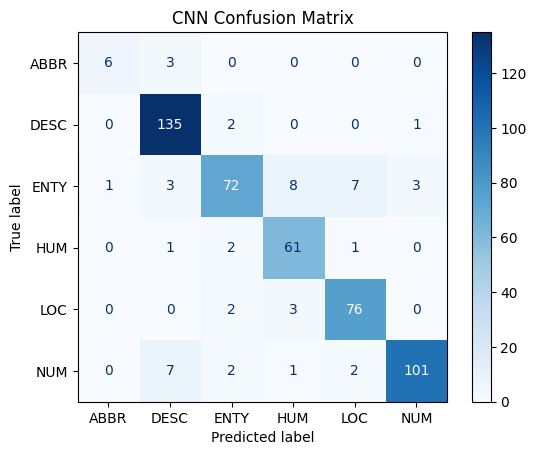

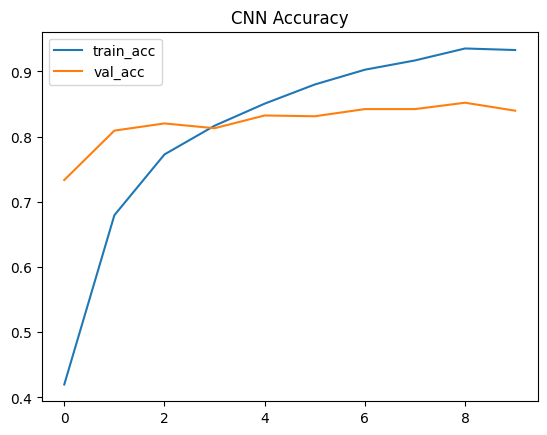

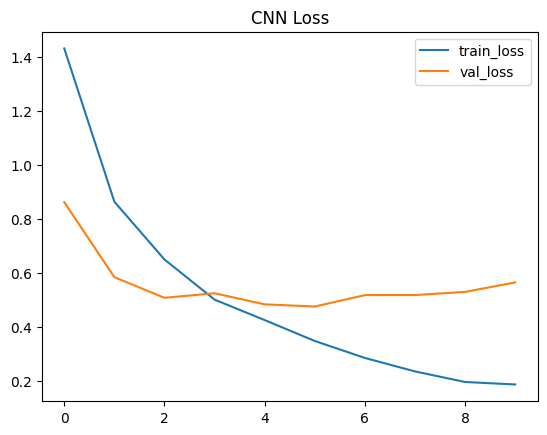

In [42]:
# Parameters
max_len = 50
embedding_dim = embedding_matrix.shape[1]
vocab_size = embedding_matrix.shape[0]

# Build CNN model
cnn_model = Sequential()
cnn_model.add(Embedding(input_dim=vocab_size,
                        output_dim=embedding_dim,
                        weights=[embedding_matrix],
                        input_length=max_len,
                        trainable=False))

cnn_model.add(tf.keras.layers.Conv1D(128, 5, activation='relu'))
cnn_model.add(tf.keras.layers.GlobalMaxPooling1D())
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(6, activation='softmax'))   

# Compile mode
cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
history_cnn = cnn_model.fit(X_train_seq, y_train_cat,epochs=10, batch_size=32, validation_data=(X_val_seq, y_val_cat))

# Evaluate model
loss_cnn, acc_cnn = cnn_model.evaluate(X_test_seq, y_test_cat)
print('CNN Test Accuracy: %.4f' % acc_cnn)
print('CNN Test Loss:', loss_cnn)
print(f"Test Accuracy (CNN): {acc_cnn:.4f}")

# Predictions and conf matrix
y_pred_cnn = cnn_model.predict(X_test_seq)
y_pred_classes = y_pred_cnn.argmax(axis=1)
y_true = y_test_cat.argmax(axis=1)

plt.figure(figsize=(6,5))

display_confusion_matrix(y_true, y_pred_classes, "CNN Confusion Matrix")

# Training history plot
plt.plot(history_cnn.history['accuracy'], label='train_acc')
plt.plot(history_cnn.history['val_accuracy'], label='val_acc')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

plt.plot(history_cnn.history['loss'], label='train_loss')
plt.plot(history_cnn.history['val_loss'], label='val_loss')
plt.title('CNN Loss')
plt.legend()
plt.show()

## RNN

Epoch 1/10


c:\Users\mw710\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


145/145 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.4827 - loss: 1.2908 - val_accuracy: 0.7115 - val_loss: 0.8306
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7333 - loss: 0.7442 - val_accuracy: 0.7800 - val_loss: 0.6508
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7997 - loss: 0.5797 - val_accuracy: 0.7677 - val_loss: 0.6539
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8392 - loss: 0.4924 - val_accuracy: 0.8154 - val_loss: 0.5589
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8526 - loss: 0.4437 - val_accuracy: 0.8264 - val_loss: 0.5089
Epoch 6/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8770 - loss: 0.3797 - val_accuracy: 0.8068 - val_loss: 0.5418
Epoch 7/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8766 - loss: 0.3615 - val_accuracy: 0.8007 - val_loss: 0.5982
Epoch 8/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8940 - loss: 0.3239 - val_accuracy: 0.820

<Figure size 600x500 with 0 Axes>

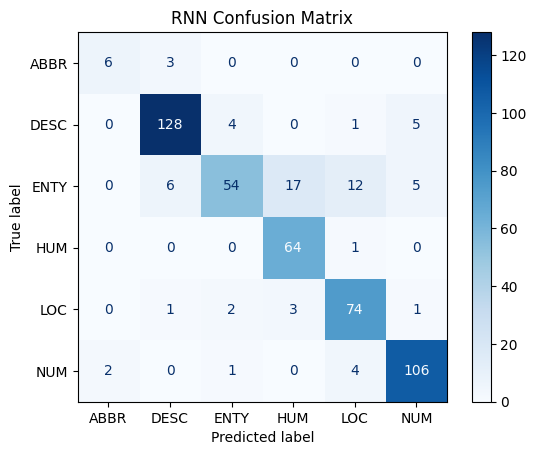

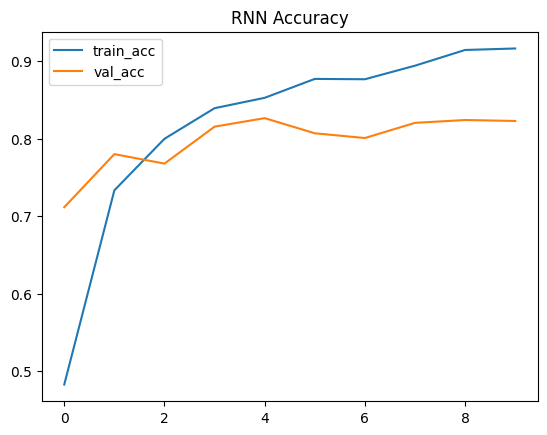

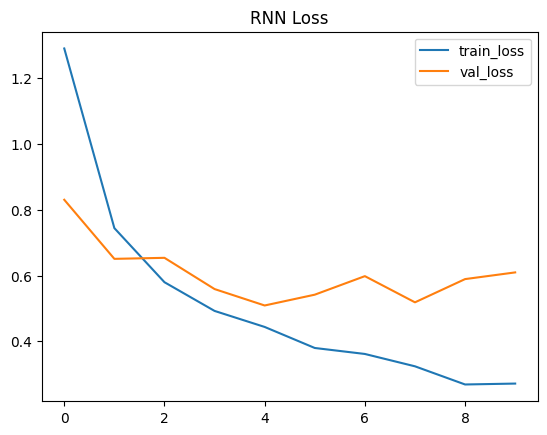

In [ ]:
# Reuses parameters defined in CNN

# Build RNN model
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,  weights=[embedding_matrix], input_length=max_len, trainable=False))
rnn_model.add(LSTM(128, return_sequences=False))
rnn_model.add(Dropout(0.5))
rnn_model.add(Dense(128, activation='relu'))
rnn_model.add(Dense(6, activation='softmax'))

# Complie model 
rnn_model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

# Train model  
history_rnn = rnn_model.fit(X_train_seq, y_train_cat, epochs=10, batch_size=32, validation_data=(X_val_seq, y_val_cat))

# Evaluate model
loss_rnn, acc_rnn = rnn_model.evaluate(X_test_seq, y_test_cat)
print('RNN Test Accuracy: %.4f' % acc_rnn)
print('RNN Test Loss:', loss_rnn)
print(f"Test Accuracy (RNN): {acc_rnn:.4f}")

# Predictions and conf matrix
y_pred_rnn = rnn_model.predict(X_test_seq)
y_pred_classes = y_pred_rnn.argmax(axis=1)
y_true = y_test_cat.argmax(axis=1)

plt.figure(figsize=(6,5))

display_confusion_matrix(y_true, y_pred_classes, "RNN Confusion Matrix")

# Training history plot
plt.plot(history_rnn.history['accuracy'], label='train_acc')
plt.plot(history_rnn.history['val_accuracy'], label='val_acc' )
plt.title('RNN Accuracy')
plt.legend()
plt.show()

plt.plot(history_rnn.history['loss'], label='train_loss')
plt.plot(history_rnn.history['val_loss'], label='val_loss')
plt.title('RNN Loss')
plt.legend()
plt.show()